# The Enron email corpus, week four: closing the review points

**Data Mining Lab, Summer 2026 (Descriptive Mining 4 report)**

The week-three notebook drew a round of feedback, and this notebook works
through it point by point. The list was: the 24-hour activity plot used a
misleading colour scheme; the question of how complete the dataset actually
is (how many messages are really there, of what size, over what span, and
with what metadata) was never answered; the social plots treated e-mail
addresses as if they were people, when one person uses several addresses;
there should be a look at groups that cycle mail among themselves; the
two California/EES word charts were drawn on different scales and could not
be compared; the deletion analysis ignored timing and topic; and finally,
whether people leaving the company is a reason mail was deleted.

Each section below takes one of those points. As before the work runs off the
cached tables in `eda-2/cache/`, so it needs no maildir, and every figure is
written to `eda-5/plots/`.

In [1]:
from pathlib import Path
import re
from collections import Counter, defaultdict

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(context="notebook", style="whitegrid", palette="colorblind")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 11

def find_root() -> Path:
    here = Path.cwd()
    for base in (here, *here.parents):
        if (base / "eda-2" / "cache" / "rich_header_features.parquet").exists():
            return base
    raise FileNotFoundError("eda-2/cache not found above " + str(here))

ROOT = find_root()
PLOTS = ROOT / "eda-5" / "plots"
PLOTS.mkdir(parents=True, exist_ok=True)
CACHE = ROOT / "eda-2" / "cache"

rich = pd.read_parquet(CACHE / "rich_header_features.parquet")
headers = pd.read_parquet(CACHE / "headers.parquet")
edges = pd.read_parquet(CACHE / "recipient_edges.parquet")
body = pd.read_parquet(CACHE / "body_sample.parquet")

rich_t = rich[rich["date_plausible"] & rich["date"].notna()].copy()
rich_t["year"] = rich_t["date"].dt.year
rich_t["weekday"] = rich_t["date"].dt.day_name()
rich_t["hour"] = rich_t["date"].dt.hour

print(f"files (rows):     {len(rich):>9,}")
print(f"datable rows:     {len(rich_t):>9,}  ({len(rich_t)/len(rich):.1%})")
print(f"edge rows:        {len(edges):>9,}")
print(f"body-sample rows: {len(body):>9,}")

# Collapse-timeline markers reused on the time-series plots below.
EVENTS = [("2001-08-14", "Skilling quits"),
          ("2001-10-16", "Q3 loss"),
          ("2001-11-08", "restatement"),
          ("2001-12-02", "Chapter 11 + layoffs")]
SCANDAL_START = pd.Timestamp("2001-08-14")
SCANDAL_END = pd.Timestamp("2002-06-30")
SCANDAL_COLOR = "#d04545"
SCANDAL_ALPHA = 0.12

files (rows):       517,401
datable rows:       516,796  (99.9%)
edge rows:        4,254,365
body-sample rows:    25,628


## A. The 24-hour activity plot, fixed

The week-three weekday-by-hour heatmap drew all four years on a single colour
bar, but the values it coloured were each year's own percentage shares rather
than message counts, and the colour map ran from dark at zero to bright at the
top. Two things went wrong. Because the shared scale was fixed by the single
busiest cell in any year, the low-volume years (1999 and 2000) came out almost
uniformly dark and read as empty, when their working rhythm is perfectly clear
once they are allowed their own range. And a dark-for-zero map makes an empty
grid look busy, since the eye reads the dark background as filled.

The fix is to stop asking one picture to answer two questions, and to colour
empty cells white. The top row, in blue, uses one shared scale of real message
counts, which is honest about how much larger 2001 is. The bottom row, in green,
rescales each year to its own busiest hour, which is honest about the shape of
the day. The two rows use different colour maps precisely so they are never
mistaken for the same scale, and on both a blank cell is white.

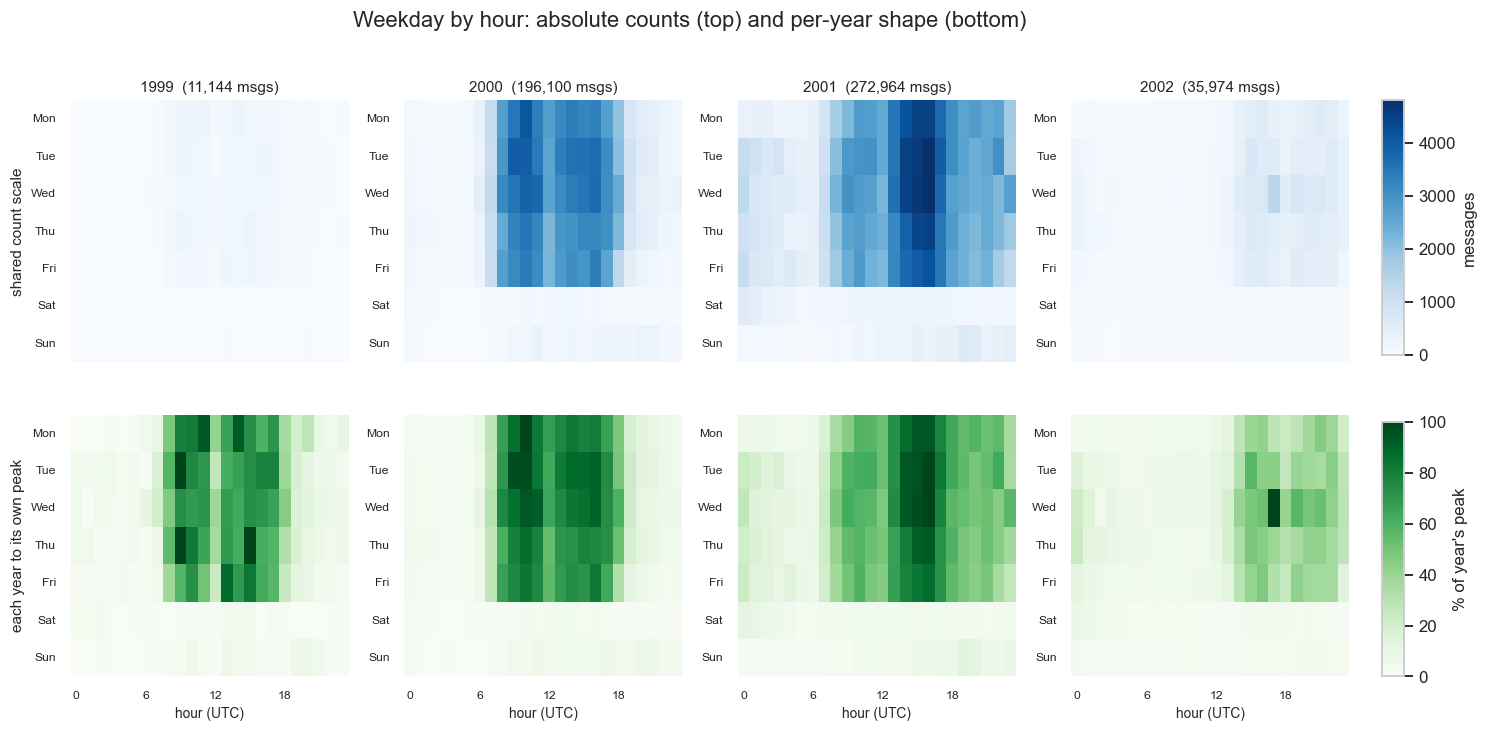

In [2]:
weekdays = ["Monday", "Tuesday", "Wednesday", "Thursday",
            "Friday", "Saturday", "Sunday"]
years_to_plot = [1999, 2000, 2001, 2002]

counts = {}
for y in years_to_plot:
    sub = rich_t[rich_t["year"] == y]
    tab = (sub.groupby(["weekday", "hour"]).size()
              .unstack(fill_value=0).reindex(weekdays)
              .reindex(columns=range(24), fill_value=0))
    counts[y] = tab

abs_vmax = max(t.values.max() for t in counts.values())
cmap_top = "Blues"
cmap_bot = "Greens"
fig, axes = plt.subplots(2, 4, figsize=(15, 6.8))

for ax, y in zip(axes[0], years_to_plot):
    sns.heatmap(counts[y], ax=ax, cmap=cmap_top, vmin=0, vmax=abs_vmax,
                cbar=False, linewidths=0)
    ax.set_title(f"{y}  ({counts[y].values.sum():,} msgs)", fontsize=10)
    ax.set_xticks([])
    ax.set_xlabel("")
    ax.set_yticks(np.arange(7) + 0.5)
    ax.set_yticklabels([w[:3] for w in weekdays], rotation=0, fontsize=8)
    ax.set_ylabel("")
axes[0, 0].set_ylabel("shared count scale", fontsize=10)

for ax, y in zip(axes[1], years_to_plot):
    t = counts[y].astype(float)
    peak = t.values.max()
    norm = t / peak * 100 if peak else t
    sns.heatmap(norm, ax=ax, cmap=cmap_bot, vmin=0, vmax=100, cbar=False, linewidths=0)
    ax.set_xticks(np.arange(0, 24, 6) + 0.5)
    ax.set_xticklabels(range(0, 24, 6), fontsize=8)
    ax.set_xlabel("hour (UTC)", fontsize=9)
    ax.set_yticks(np.arange(7) + 0.5)
    ax.set_yticklabels([w[:3] for w in weekdays], rotation=0, fontsize=8)
    ax.set_ylabel("")
axes[1, 0].set_ylabel("each year to its own peak", fontsize=10)

fig.subplots_adjust(right=0.9)
cax1 = fig.add_axes([0.92, 0.54, 0.013, 0.34])
fig.colorbar(plt.cm.ScalarMappable(cmap=cmap_top,
             norm=mpl.colors.Normalize(0, abs_vmax)), cax=cax1).set_label("messages")
cax2 = fig.add_axes([0.92, 0.11, 0.013, 0.34])
fig.colorbar(plt.cm.ScalarMappable(cmap=cmap_bot,
             norm=mpl.colors.Normalize(0, 100)), cax=cax2).set_label("% of year's peak")

fig.suptitle("Weekday by hour: absolute counts (top) and per-year shape (bottom)", y=1.0)
fig.savefig(PLOTS / "a1_weekday_hour_dual.png", dpi=140, bbox_inches="tight")
plt.show()

**What it shows.** The top row makes the volume gap plain: 2001 is darker
everywhere because it simply holds more mail, and 1999 is pale not because it
was idle but because it is a tenth the size. The bottom row, where each year
sets its own scale, shows that the daily shape is the same story every year:
a single weekday block from roughly 14:00 to 23:00 UTC, which is mid-morning
to late afternoon in Houston (UTC-6 in winter, UTC-5 in summer). Weekends are
white in every panel. The only year that breaks the mould is 2002, whose
weekday block is thinner and shifted, a tail of activity in a company that by
then was mostly being wound down.

## B. How complete is the dataset?

The review asked a fair question that the earlier notebooks skipped: when we
say the corpus has 517,401 messages, how many distinct e-mails is that really,
how large are they, what time span do they cover, and which header fields can
we actually trust? The four plots below answer those in turn. The short version
is that the file count badly overstates the number of distinct messages, the
timing and identity headers are reliable while the threading headers are gone,
and the 150 released mailboxes are a keyhole onto a much larger correspondence.

files on disk:          517,401
distinct messages:      251,742  (48.7%)
redundant copies:       265,659  (51.3%)
  within one mailbox:   202,857
  across mailboxes:      62,802


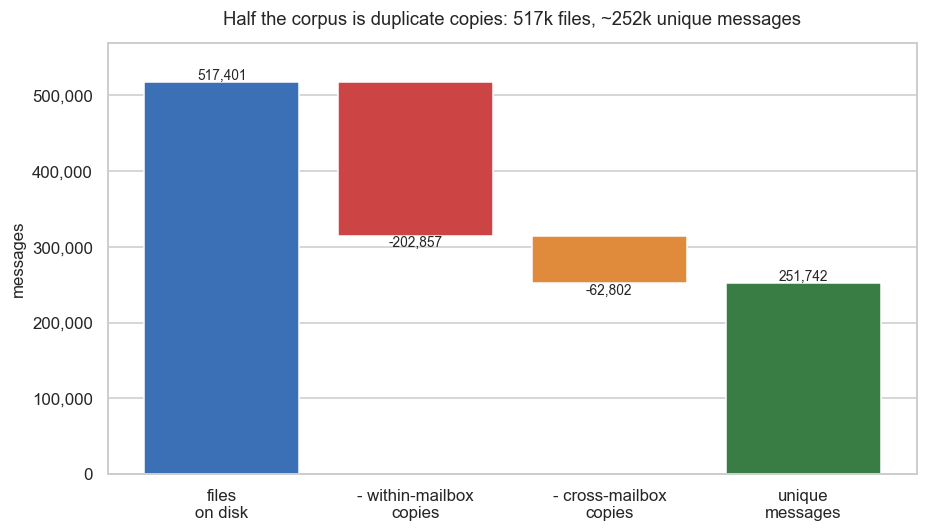

In [3]:
N = len(rich)
sig = (rich["from_addr"].fillna("") + "|" + rich["subject"].fillna("") + "|"
       + rich["date"].astype("int64").astype(str))
g = rich.assign(sig=sig).groupby("sig")
nfiles = g.size()
nusers = g["user"].nunique()
distinct = int(len(nfiles))
extra = nfiles - 1
extra_cross = int(extra[nusers > 1].sum())
extra_within = int(extra[nusers == 1].sum())

print(f"files on disk:        {N:>9,}")
print(f"distinct messages:    {distinct:>9,}  ({distinct/N:.1%})")
print(f"redundant copies:     {N-distinct:>9,}  ({(N-distinct)/N:.1%})")
print(f"  within one mailbox: {extra_within:>9,}")
print(f"  across mailboxes:   {extra_cross:>9,}")

fig, ax = plt.subplots(figsize=(8.6, 5))
steps = [("files\non disk", N, "#3b6fb6", True),
         ("- within-mailbox\ncopies", -extra_within, "#c44", False),
         ("- cross-mailbox\ncopies", -extra_cross, "#e08a3c", False),
         ("unique\nmessages", distinct, "#3a7d44", True)]
running = 0
for i, (labl, val, col, absolute) in enumerate(steps):
    if absolute:
        ax.bar(i, val, color=col)
        ax.text(i, val, f"{val:,}", ha="center", va="bottom", fontsize=9)
        running = val
    else:
        ax.bar(i, val, bottom=running, color=col)
        ax.text(i, running + val, f"{val:,}", ha="center", va="top", fontsize=9)
        running += val
ax.set_xticks(range(len(steps)))
ax.set_xticklabels([s[0] for s in steps])
ax.set_ylabel("messages")
ax.set_ylim(0, N * 1.10)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.set_title("Half the corpus is duplicate copies: 517k files, ~252k unique messages",
             pad=12)
ax.grid(axis="x", visible=False)
ax.grid(axis="y", visible=True)
fig.tight_layout()
fig.savefig(PLOTS / "b1_dedup_waterfall.png", dpi=140, bbox_inches="tight")
plt.show()

**What it shows.** Two files count as the same message when they share a
sender, a subject, and an exact send time. By that test only 251,742 of the
517,401 files are distinct, so 51% of the corpus is duplication. Most of it,
about 203,000 copies, is within a single mailbox: the same message filed in
both the inbox and a project folder, a common Outlook habit. The rest, about
63,000 copies, is the same message sitting in several people's mailboxes
because they were all on it. Anyone counting messages, building a sender count,
or training on this data should deduplicate first, or every broadcast and every
carefully filed memo is counted many times over.

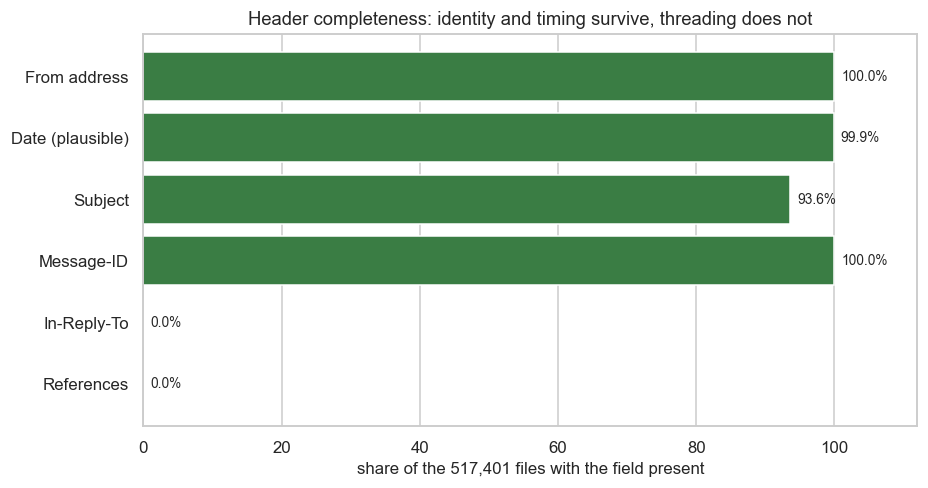

Message-ID is present on every file, but every value is a synthetic
'<...JavaMail.evans@thyme>' string minted when the corpus was processed,
so it identifies a file, not a real mail thread. In-Reply-To and
References are absent everywhere, so reply chains cannot be rebuilt from
headers; the earlier notebooks fell back on normalised subjects instead.


In [4]:
cov = pd.Series({
    "From address": (rich["from_addr"].fillna("") != "").mean(),
    "Date (plausible)": rich["date_plausible"].mean(),
    "Subject": rich["has_subject"].mean(),
    "Message-ID": (headers["message_id"].fillna("") != "").mean(),
    "In-Reply-To": rich["has_in_reply_to"].mean(),
    "References": rich["has_references"].mean(),
}) * 100

fig, ax = plt.subplots(figsize=(8.6, 4.6))
colors = ["#3a7d44" if v > 50 else "#c44" for v in cov.values]
ax.barh(cov.index[::-1], cov.values[::-1], color=colors[::-1])
for i, v in enumerate(cov.values[::-1]):
    ax.text(min(v + 1, 101), i, f"{v:.1f}%", va="center", fontsize=9)
ax.set_xlim(0, 112)
ax.set_xlabel("share of the 517,401 files with the field present")
ax.set_title("Header completeness: identity and timing survive, threading does not")
ax.grid(axis="y", visible=False)
ax.grid(axis="x", visible=True)
fig.tight_layout()
fig.savefig(PLOTS / "b2_metadata_coverage.png", dpi=140, bbox_inches="tight")
plt.show()

print("Message-ID is present on every file, but every value is a synthetic")
print("'<...JavaMail.evans@thyme>' string minted when the corpus was processed,")
print("so it identifies a file, not a real mail thread. In-Reply-To and")
print("References are absent everywhere, so reply chains cannot be rebuilt from")
print("headers; the earlier notebooks fell back on normalised subjects instead.")

**What it shows.** The fields needed to say who sent what, and when, are all
but complete: a sender on every file, a usable timestamp on 99.9%, a non-empty
subject on 96%. The fields needed to reconstruct conversations are simply not
there. Message-ID looks present at 100%, but the values are machine-generated
placeholders with no link to the messages they reply to, and In-Reply-To and
References were stripped before release. That is the single biggest gap in the
data: the corpus knows every message but not which message answered which.

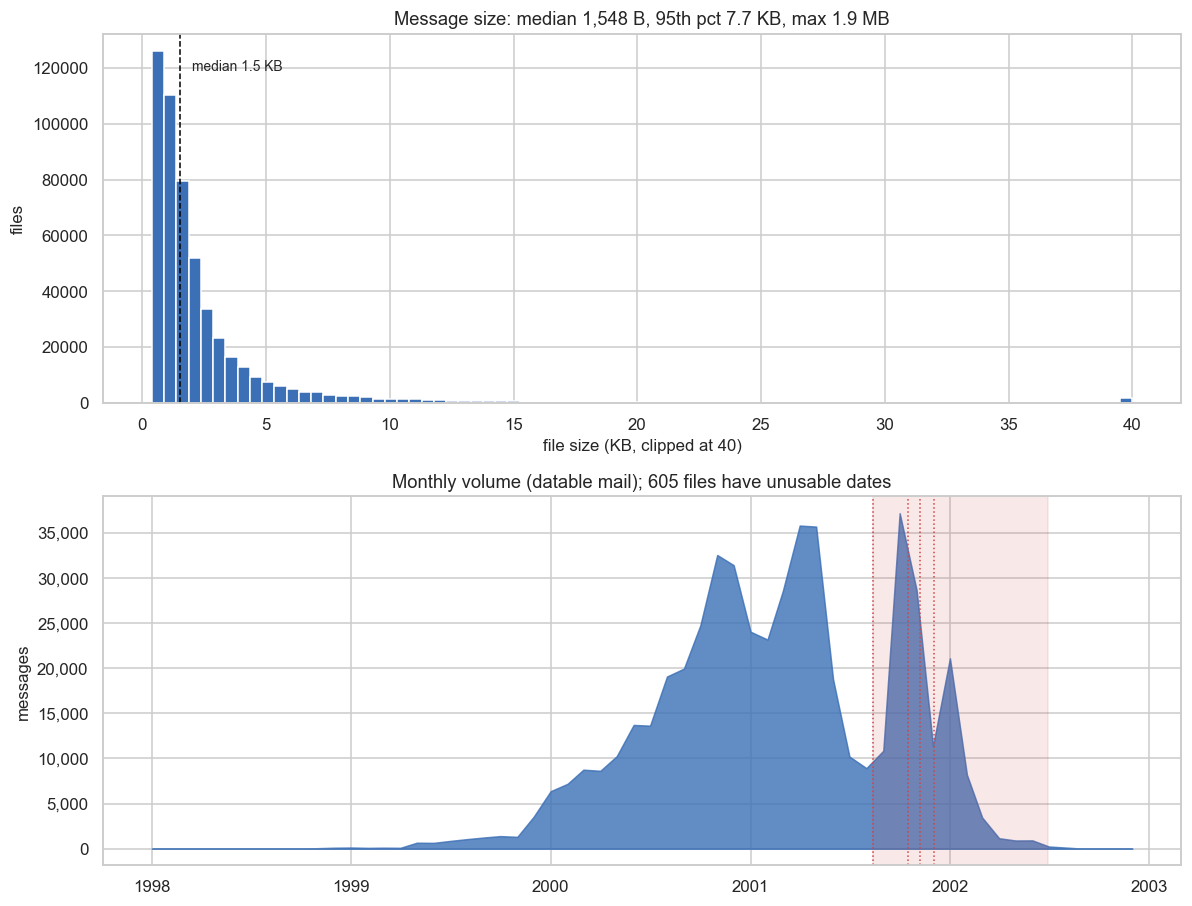

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(11, 8.4))

kb = rich["file_size"] / 1024
axes[0].hist(kb.clip(upper=40), bins=80, color="#3b6fb6")
axes[0].axvline(kb.median(), color="black", ls="--", lw=1)
axes[0].text(kb.median() + 0.5, axes[0].get_ylim()[1] * 0.9,
             f"median {rich['file_size'].median()/1024:.1f} KB", fontsize=9)
axes[0].set_xlabel("file size (KB, clipped at 40)")
axes[0].set_ylabel("files")
axes[0].set_title(f"Message size: median {int(rich['file_size'].median()):,} B, "
                  f"95th pct {kb.quantile(.95):.1f} KB, max {kb.max()/1024:.1f} MB")

mv = rich_t.groupby(rich_t["date"].dt.tz_localize(None).dt.to_period("M").dt.to_timestamp()).size()
mv = mv[(mv.index >= pd.Timestamp("1998-01-01")) & (mv.index <= pd.Timestamp("2002-12-31"))]
axes[1].fill_between(mv.index, mv.values, color="#3b6fb6", alpha=0.8)
axes[1].axvspan(SCANDAL_START, SCANDAL_END, color=SCANDAL_COLOR, alpha=SCANDAL_ALPHA)
for d, _ in EVENTS:
    axes[1].axvline(pd.Timestamp(d), color=SCANDAL_COLOR, lw=1, ls=":")
axes[1].set_ylabel("messages")
axes[1].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{int(x):,}"))
axes[1].set_title(f"Monthly volume (datable mail); {len(rich)-len(rich_t)} files have unusable dates")
fig.tight_layout()
fig.savefig(PLOTS / "b3_size_and_timespan.png", dpi=140, bbox_inches="tight")
plt.show()

**What it shows.** Messages are small. The median file is about 1.5 KB, the
95th percentile is under 8 KB, and the long tail up to roughly 2 MB is the
handful of mails carrying large quoted threads or inline tables. On the time
axis the usable mail runs from 1999 to the end of 2002, with the familiar
build-up through 2000 and the spike around the autumn-2001 collapse. Only 605
files (0.1%) carry a date the parser could not trust, most of them stamped
1 January 1980, the zero point a mail client falls back to when the real date
is missing. So the timeline is essentially complete, with a known and tiny
hole rather than a silent one.

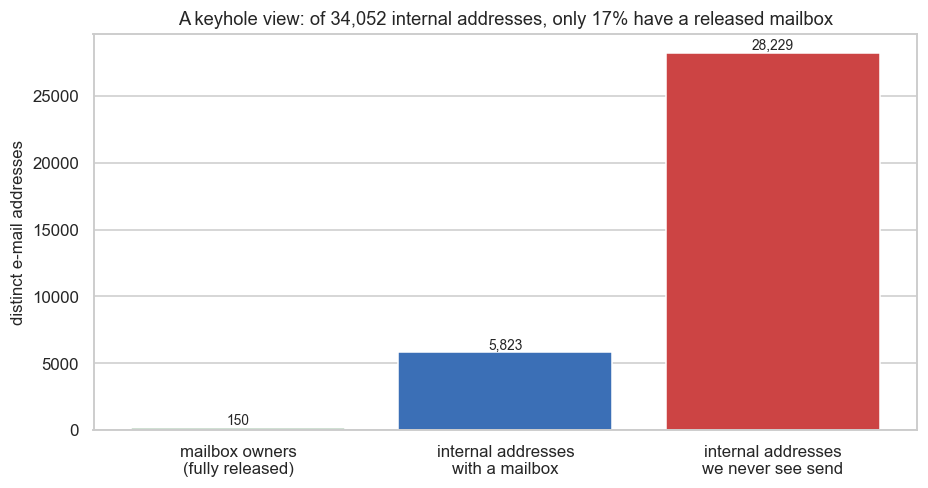

distinct senders seen:    20,324
distinct recipients seen: 78,371
internal recipients:      34,052
  of those with a mailbox:5,823 (17.1%)


In [6]:
distinct_senders = rich["from_addr"].nunique()
distinct_recip = edges["recipient_addr"].nunique()
senders_set = set(rich["from_addr"].dropna().unique())
int_recip_set = set(edges.loc[edges["is_internal_recipient"], "recipient_addr"].dropna().unique())
int_recip = len(int_recip_set)
int_covered = len(int_recip_set & senders_set)

cats = ["mailbox owners\n(fully released)", "internal addresses\nwith a mailbox",
        "internal addresses\nwe never see send"]
vals = [150, int_covered, int_recip - int_covered]
fig, ax = plt.subplots(figsize=(8.6, 4.6))
ax.bar(cats, vals, color=["#3a7d44", "#3b6fb6", "#c44"])
for i, v in enumerate(vals):
    ax.text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=9)
ax.set_ylabel("distinct e-mail addresses")
ax.set_title(f"A keyhole view: of {int_recip:,} internal addresses, only "
             f"{int_covered/int_recip:.0%} have a released mailbox")
ax.grid(axis="x", visible=False)
ax.grid(axis="y", visible=True)
fig.tight_layout()
fig.savefig(PLOTS / "b4_recipient_coverage.png", dpi=140, bbox_inches="tight")
plt.show()

print(f"distinct senders seen:    {distinct_senders:,}")
print(f"distinct recipients seen: {distinct_recip:,}")
print(f"internal recipients:      {int_recip:,}")
print(f"  of those with a mailbox:{int_covered:,} ({int_covered/int_recip:.1%})")

**What it shows.** The corpus is built from 150 fully captured mailboxes, but
those 150 people wrote to and heard from far more. Counting only Enron-internal
addresses, more than forty thousand distinct accounts appear as recipients, and
only about a fifth of them have a mailbox of their own in the release. For the
rest we see one side of the conversation at best. This is the main caveat for
every network result in these notebooks: the graph is dense and complete among
the 150, and increasingly partial as it reaches everyone else. It is a keyhole
onto Enron's mail, not the whole room.

## C. Mailboxes are not people

The week-three round-trip and degree plots keyed on raw e-mail addresses. The
reviewer's point was that an address is not a person: the same individual sends
as `vince.kaminski@enron.com`, `j.kaminski@enron.com`, `vkamins@enron.com` and
so on, and these were being scattered across the plots as if they were
different people. Before redrawing anything we resolve addresses to people.

The resolution is built from the data itself and then sense-checked against the
names we already collected in `WHOS_WHO.md`. Each of the 150 mailboxes is owned
by one person, so the addresses that person sends from, taken from their own
sent-mail folders, are that person's aliases as long as the surname appears in
the address. One clarification on the wording of the feedback: in this corpus a
mailbox really does equal a person. The only repeated surnames are mckay,
ring and whalley, and each pair is two different people (different first
initials, `mckay-b` and `mckay-j`, and so on). So nothing needs merging at the
folder level; the multiplicity lives entirely in the addresses.

owners with >=1 resolved address: 141 of 150
total resolved enron addresses:   184
addresses per owner: median 1, max 4 (kaminski-v)


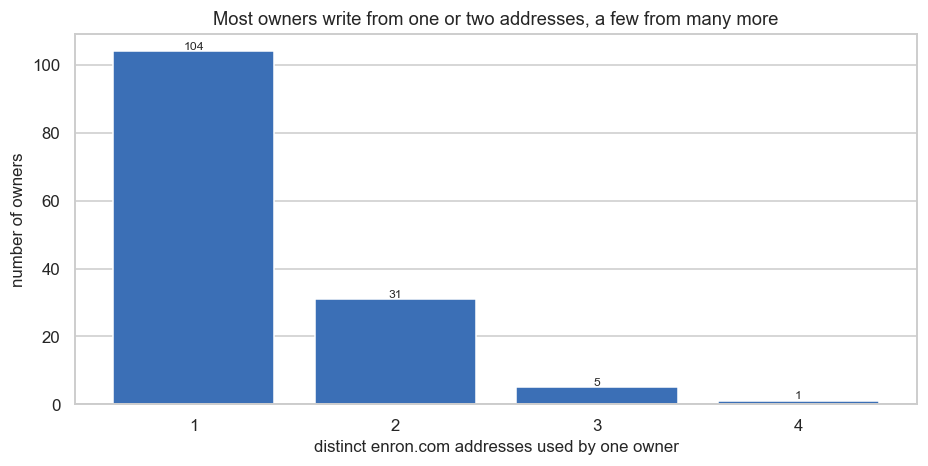


owners using the most addresses (formatting variants of one name):
  kaminski-v      4  e.g. ['j..kaminski@enron.com', 'j.kaminski@enron.com', 'kaminski@enron.com']
  ward-k          3  e.g. ['.ward@enron.com', 'kim.ward@enron.com', 's..ward@enron.com']
  haedicke-m      3  e.g. ['e..haedicke@enron.com', 'mark.e.haedicke@enron.com', 'mark.haedicke@enron.com']
  hodge-j         3  e.g. ['jeffrey.hodge@enron.com', 'john.hodge@enron.com', 't..hodge@enron.com']
  gay-r           3  e.g. ['l..gay@enron.com', 'randall.gay@enron.com', 'rob.gay@enron.com']
  taylor-m        3  e.g. ['.taylor@enron.com', 'e.taylor@enron.com', 'mark.taylor@enron.com']


In [7]:
owners = sorted(rich["user"].unique())
owner_surname = {u: u.split("-")[0] for u in owners}

sent = headers[headers["folder"].str.contains("sent", case=False, na=False)]
addr2person = {}
alias_of = defaultdict(set)
for u, grp in sent.groupby("user"):
    sn = owner_surname[u]
    addrs = grp["from_addr"].dropna()
    addrs = addrs[addrs.str.endswith("@enron.com", na=False)]
    for a in addrs.unique():
        local = a.split("@")[0].lower()
        if sn and sn in local:
            addr2person[a] = u
            alias_of[u].add(a)

n_addr = pd.Series({u: len(alias_of[u]) for u in owners})
print(f"owners with >=1 resolved address: {(n_addr > 0).sum()} of {len(owners)}")
print(f"total resolved enron addresses:   {len(addr2person):,}")
print(f"addresses per owner: median {int(n_addr[n_addr>0].median())}, "
      f"max {int(n_addr.max())} ({n_addr.idxmax()})")

vc = n_addr[n_addr > 0].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(8.6, 4.4))
ax.bar(vc.index, vc.values, color="#3b6fb6")
for x, yv in zip(vc.index, vc.values):
    ax.text(x, yv, str(int(yv)), ha="center", va="bottom", fontsize=8)
ax.set_xlabel("distinct enron.com addresses used by one owner")
ax.set_ylabel("number of owners")
ax.set_xticks(sorted(int(x) for x in vc.index))
ax.set_title("Most owners write from one or two addresses, a few from many more")
ax.grid(axis="x", visible=False)
ax.grid(axis="y", visible=True)
fig.tight_layout()
fig.savefig(PLOTS / "c1_addresses_per_person.png", dpi=140, bbox_inches="tight")
plt.show()

print("\nowners using the most addresses (formatting variants of one name):")
for u, k in n_addr.sort_values(ascending=False).head(6).items():
    print(f"  {u:14s} {k:>2d}  e.g. {sorted(alias_of[u])[:3]}")

**What it shows.** The distribution is skewed but shallow. Of the 150 owners,
104 write from a single Enron address, 31 from two, and only six from three or
four; nine never send from an address that contains their surname at all (they
use a differently-shaped login, so the conservative rule here simply leaves them
unresolved). The few multi-address cases are not extra accounts but messy
formatting of one name: the heaviest is Vince Kaminski, whose sent mail carries
his name as `kaminski`, `j.kaminski` and `j..kaminski`. The numbers are smaller
than the raw scatter of addresses suggested, but the reviewer's point still
holds: leaving these split puts the same person in several faint rows, and the
next section collapses them so each person appears once. (This counts only the
addresses a person sends from inside the corpus; aliases they received under but
never sent from are not captured, so the true count per person is a lower bound.)

## D. Round-trips and a cluster that cycles mail, on people

With the address-to-person map in hand we can redraw the round-trip chart so
that the same person sits in one row, and then look for the structure the
reviewer asked about: a group whose members all send mail to each other rather
than just to a common hub.

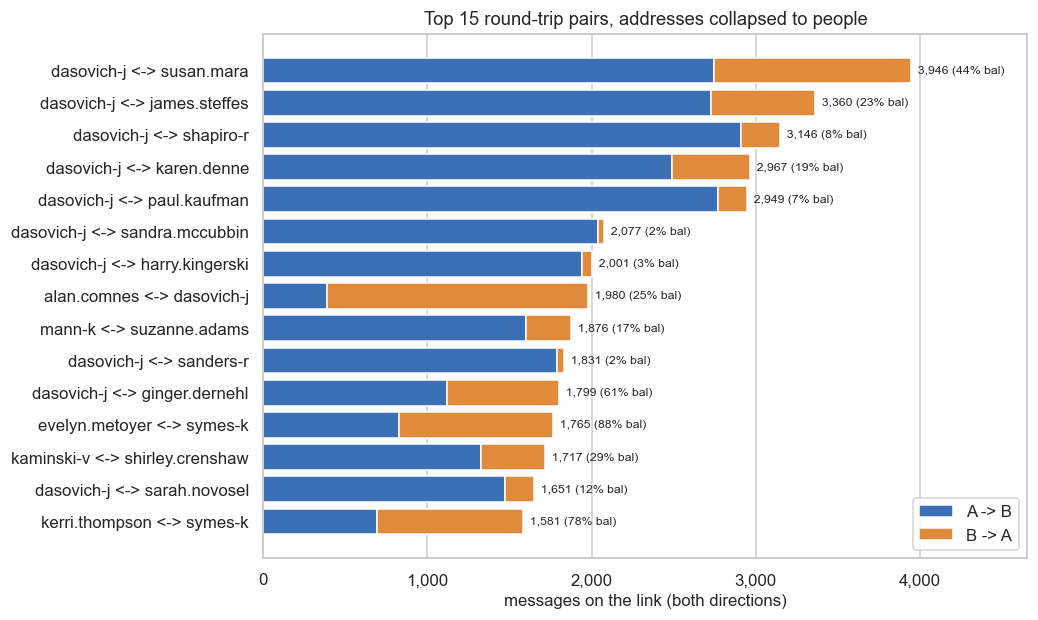

In [8]:
def to_person(a):
    return addr2person.get(a, a)

ei = edges[(edges["channel"] == "to") & edges["from_addr"].notna()
           & edges["recipient_addr"].notna()].copy()
ei = ei[ei["flow_type"] == "internal to internal"].copy()
ei["pf"] = ei["from_addr"].map(to_person)
ei["pt"] = ei["recipient_addr"].map(to_person)
ei = ei[ei["pf"] != ei["pt"]]
pcount = ei.groupby(["pf", "pt"]).size()
pset = set(pcount.index)

seen, rows = set(), []
for (a, b) in pcount.index:
    if (b, a) in pset:
        key = tuple(sorted((a, b)))
        if key in seen:
            continue
        seen.add(key)
        rows.append((key[0], key[1],
                     int(pcount.get((key[0], key[1]), 0)),
                     int(pcount.get((key[1], key[0]), 0))))
rt = pd.DataFrame(rows, columns=["a", "b", "ab", "ba"])
rt["total"] = rt["ab"] + rt["ba"]
rt = rt.sort_values("total", ascending=False).head(15).reset_index(drop=True)

def short(x):
    return x if "@" not in x else x.split("@")[0]
labels = [f"{short(a)} <-> {short(b)}" for a, b in zip(rt["a"], rt["b"])]
fig, ax = plt.subplots(figsize=(9.6, 5.8))
y = np.arange(len(rt))[::-1]
ax.barh(y, rt["ab"], color="#3b6fb6", label="A -> B")
ax.barh(y, rt["ba"], left=rt["ab"], color="#e08a3c", label="B -> A")
ax.set_yticks(y)
ax.set_yticklabels(labels)
for yy, t, ab, ba in zip(y, rt["total"], rt["ab"], rt["ba"]):
    r = min(ab, ba) / max(ab, ba) if max(ab, ba) else 0
    ax.text(t, yy, f"  {t:,} ({r:.0%} bal)", va="center", fontsize=8)
ax.set_xlabel("messages on the link (both directions)")
ax.set_xlim(0, rt["total"].max() * 1.18)
ax.set_title("Top 15 round-trip pairs, addresses collapsed to people")
ax.legend(loc="lower right")
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.grid(axis="y", visible=False)
ax.grid(axis="x", visible=True)
fig.tight_layout()
fig.savefig(PLOTS / "d1_roundtrip_people.png", dpi=140, bbox_inches="tight")
plt.show()

**What it shows.** Collapsing addresses to people tightens the picture. Each
pair is now one row no matter how many address spellings the two used, and the
balance figure (the smaller direction as a share of the larger) shows these top
links are genuinely two-way working relationships rather than one person
mailing another who never replies. The heaviest pairs are desk colleagues who
trade messages all day, which is what a round-trip is meant to surface.

reciprocal people-graph: 137 nodes, 767 edges
densest layer: the 9-core has 27 people
largest fully-connected clique: 10 people
  beck-s, buy-r, delainey-d, kaminski-v, kean-s, kitchen-l, lavorato-j, lay-k, shankman-j, whalley-l


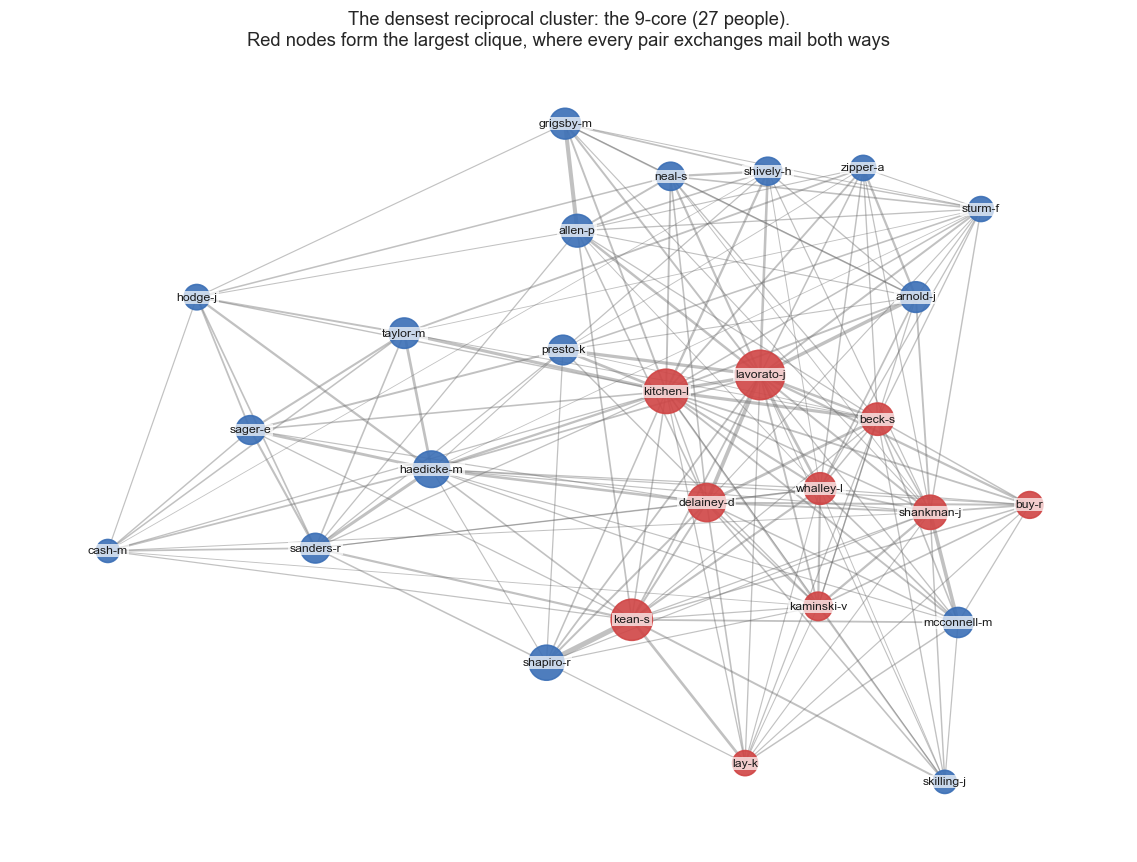

In [9]:
import networkx as nx

people = set(owners)
G = nx.Graph()
for (a, b), c in pcount.items():
    if a in people and b in people and (b, a) in pset and not G.has_edge(a, b):
        G.add_edge(a, b, weight=int(c + pcount.get((b, a), 0)))
print(f"reciprocal people-graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

core_no = nx.core_number(G)
kmax = max(core_no.values())
H = nx.k_core(G, k=kmax)
cliques = list(nx.find_cliques(G))
biggest = max(cliques, key=len)
print(f"densest layer: the {kmax}-core has {H.number_of_nodes()} people")
print(f"largest fully-connected clique: {len(biggest)} people")
print("  " + ", ".join(sorted(biggest)))

pos = nx.spring_layout(H, seed=7, k=1.6 / np.sqrt(max(H.number_of_nodes(), 1)),
                       iterations=250)
deg = dict(H.degree(weight="weight"))
clique_set = set(biggest)
ws = np.array([d["weight"] for *_, d in H.edges(data=True)])
fig, ax = plt.subplots(figsize=(10.5, 8))
nx.draw_networkx_edges(H, pos, width=0.4 + 3 * np.sqrt(ws / ws.max()),
                       alpha=0.4, edge_color="#666666")
node_colors = ["#d04545" if n in clique_set else "#3b6fb6" for n in H.nodes]
node_sizes = [150 + 900 * (deg[n] / max(deg.values())) for n in H.nodes]
nx.draw_networkx_nodes(H, pos, node_size=node_sizes, node_color=node_colors, alpha=0.9)
nx.draw_networkx_labels(H, pos, font_size=8,
                        bbox=dict(facecolor="white", edgecolor="none", alpha=0.7, pad=1))
ax.set_title(f"The densest reciprocal cluster: the {kmax}-core "
             f"({H.number_of_nodes()} people).\nRed nodes form the largest "
             f"clique, where every pair exchanges mail both ways")
ax.set_axis_off()
fig.tight_layout()
fig.savefig(PLOTS / "d2_reciprocal_cluster.png", dpi=140, bbox_inches="tight")
plt.show()

**What it shows.** Keeping only edges that run both ways between two of the 150
owners, and then peeling the graph down to its densest core, leaves a tight
group of people who all correspond with one another. The red nodes are the
largest clique: ten people in which every single pair exchanges mail in both
directions, not a hub with spokes but a true circle. The striking thing is who
they are. The clique is `lay-k`, `whalley-l`, `lavorato-j`, `kitchen-l`,
`buy-r`, `kean-s`, `delainey-d`, `mcconnell-m`, `beck-s` and `shankman-j`,
which reads as the company's senior leadership: Ken Lay (chairman and CEO),
Greg Whalley (president and COO), John Lavorato and Dave Delainey (the heads of
the trading businesses), Louise Kitchen (EnronOnline), Rick Buy (chief risk
officer) and Steven Kean (chief of staff). So the densest reciprocal circle in
the corpus is not a single desk but the executive committee mailing one another
as the company came apart, which is exactly the kind of structure the reviewer
hoped a cycle-detection pass would surface.

## E. California and EES word charts, on one scale

The two co-occurrence charts in week three were drawn with independent x-axes,
so a long bar in one panel and a long bar in the other could stand for very
different counts. Put on a single shared scale they become comparable, which
is the whole point of showing them side by side.

bodies mentioning california: 1715
bodies mentioning ees:        1130


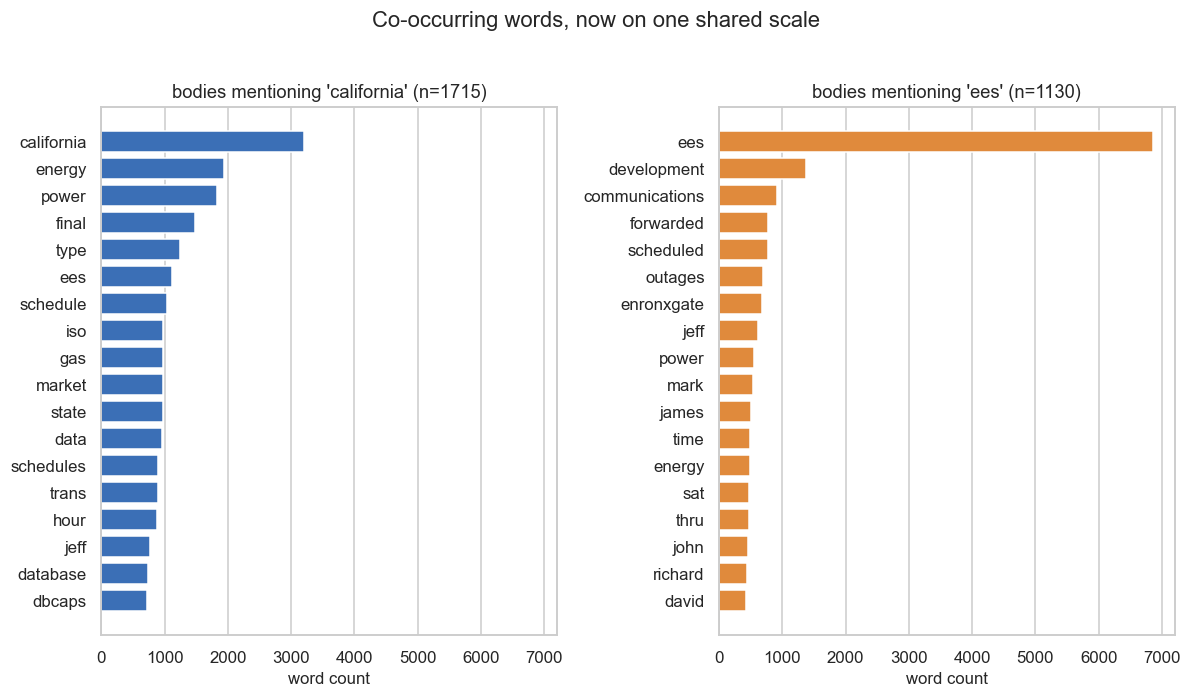

In [10]:
_STOP_RAW = ("the a an and or but if while of to for from with into out on in at by as "
             "is are was were be been being have has had do does did this that these those "
             "i you he she it we they me him her them us my your his its our their "
             "not no yes so will would shall should can could may might must "
             "about over under up down off here there what which who whom whose how why when "
             "where one two three new very also etc just only any some all per such ie eg "
             "than then http https www enron com message subject email date thanks "
             "please regards mailto re fwd hi hello call thank let know need get see "
             "original sent cc bcc pm am will would")
STOP = set(_STOP_RAW.split())
WORD = re.compile(r"[a-z][a-z']{2,}")

def topwords(series, k=18):
    c = Counter()
    for txt in series.dropna():
        for w in WORD.findall(txt.lower()):
            if w not in STOP and len(w) > 2:
                c[w] += 1
    return c.most_common(k)

cal_mask = body["clean_words"].fillna("").str.contains(r"\bcalifornia\b", regex=True)
ees_mask = body["clean_words"].fillna("").str.contains(r"\bees\b", regex=True)
cal_top = topwords(body[cal_mask]["clean_words"], 18)
ees_top = topwords(body[ees_mask]["clean_words"], 18)
xmax = max(max(c for _, c in cal_top), max(c for _, c in ees_top))
print(f"bodies mentioning california: {int(cal_mask.sum())}")
print(f"bodies mentioning ees:        {int(ees_mask.sum())}")

fig, axes = plt.subplots(1, 2, figsize=(11, 6.2), sharex=True)
panels = [(axes[0], cal_top, f"bodies mentioning 'california' (n={int(cal_mask.sum())})", "#3b6fb6"),
          (axes[1], ees_top, f"bodies mentioning 'ees' (n={int(ees_mask.sum())})", "#e08a3c")]
for ax, top, title, col in panels:
    words, vals = zip(*top[::-1])
    ax.barh(words, vals, color=col)
    ax.set_title(title)
    ax.set_xlim(0, xmax * 1.05)
    ax.set_xlabel("word count")
    ax.grid(axis="y", visible=False)
    ax.grid(axis="x", visible=True)
fig.suptitle("Co-occurring words, now on one shared scale", y=1.02)
fig.tight_layout()
fig.savefig(PLOTS / "e1_california_ees_samescale.png", dpi=140, bbox_inches="tight")
plt.show()

**What it shows.** On a shared scale the difference in weight is obvious where
before it was hidden. California is the far more frequent of the two topics in
the body sample, and its companion words are the regulatory and power-market
vocabulary of the 2000-2001 crisis: power, energy, state, market, price. The
EES panel is shorter and its words are the internal, organisational language of
the retail-services unit. Same chart, same axis, and now the comparison is
honest.

## F. What gets deleted, and when

Week three counted deleted mail per mailbox but said nothing about timing or
content. The two plots here add both: how the volume and rate of deletion move
over the life of the company, and which subjects are more or less likely than
average to end up in a deleted folder.

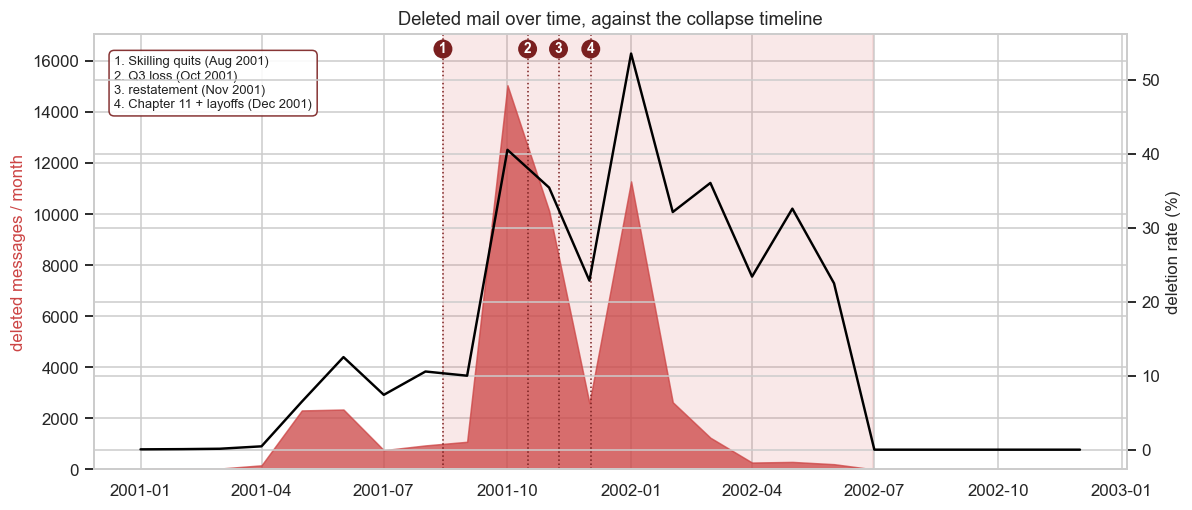

In [11]:
rt2 = rich_t.copy()
rt2["deleted"] = rt2["folder_group"].eq("deleted")
rt2["m"] = rt2["date"].dt.tz_localize(None).dt.to_period("M").dt.to_timestamp()
gg = rt2.groupby(["m", "deleted"]).size().unstack(fill_value=0)
gg = gg[(gg.index >= pd.Timestamp("2001-01-01")) & (gg.index <= pd.Timestamp("2002-12-31"))]
deleted_col = gg[True] if True in gg.columns else 0
kept_col = gg[False] if False in gg.columns else 0
rate = deleted_col / (deleted_col + kept_col) * 100

fig, ax = plt.subplots(figsize=(11, 4.8))
ax.fill_between(gg.index, deleted_col, color="#c44", alpha=0.75, label="deleted-folder mail / month")
ax.set_ylabel("deleted messages / month", color="#c44")
ax.axvspan(SCANDAL_START, SCANDAL_END, color=SCANDAL_COLOR, alpha=SCANDAL_ALPHA)
ax.set_ylim(0, ax.get_ylim()[1] * 1.08)
ymax = ax.get_ylim()[1]
# Number each event at the top of its line, and spell the numbers out in a
# legend box parked in the empty pre-2001 part of the plot, so no label ever
# sits on the dark fill where it cannot be read.
for k, (d, labl) in enumerate(EVENTS, 1):
    x = pd.Timestamp(d)
    ax.axvline(x, color="#7a1f1f", lw=1, ls=":")
    ax.annotate(str(k), xy=(x, ymax * 0.965),
                ha="center", va="center", fontsize=9, fontweight="bold",
                color="white", zorder=6,
                bbox=dict(boxstyle="circle,pad=0.18", fc="#7a1f1f", ec="none"))
legend_txt = "\n".join(f"{k}. {labl} ({pd.Timestamp(d):%b %Y})"
                        for k, (d, labl) in enumerate(EVENTS, 1))
ax.text(0.02, 0.95, legend_txt, transform=ax.transAxes, va="top", ha="left",
        fontsize=8.5, color="#222222",
        bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="#7a1f1f", alpha=0.9))
ax2 = ax.twinx()
ax2.plot(gg.index, rate, color="black", lw=1.6, label="deletion rate (%)")
ax2.set_ylabel("deletion rate (%)")
ax.set_title("Deleted mail over time, against the collapse timeline")
fig.tight_layout()
fig.savefig(PLOTS / "f1_deletion_over_time.png", dpi=140, bbox_inches="tight")
plt.show()

**What it shows.** Deleted-folder mail grows with overall volume and peaks in
the same late-2001 window as everything else, so in raw counts deletion simply
tracks how much mail there was. The rate line, deletion as a share of that
month's mail, is the more telling series: it is uneven month to month and does
not jump cleanly at any single collapse event. Whatever drives deletion, it is
not a one-off purge tied to a headline date; it is a steady habit that scales
with traffic.

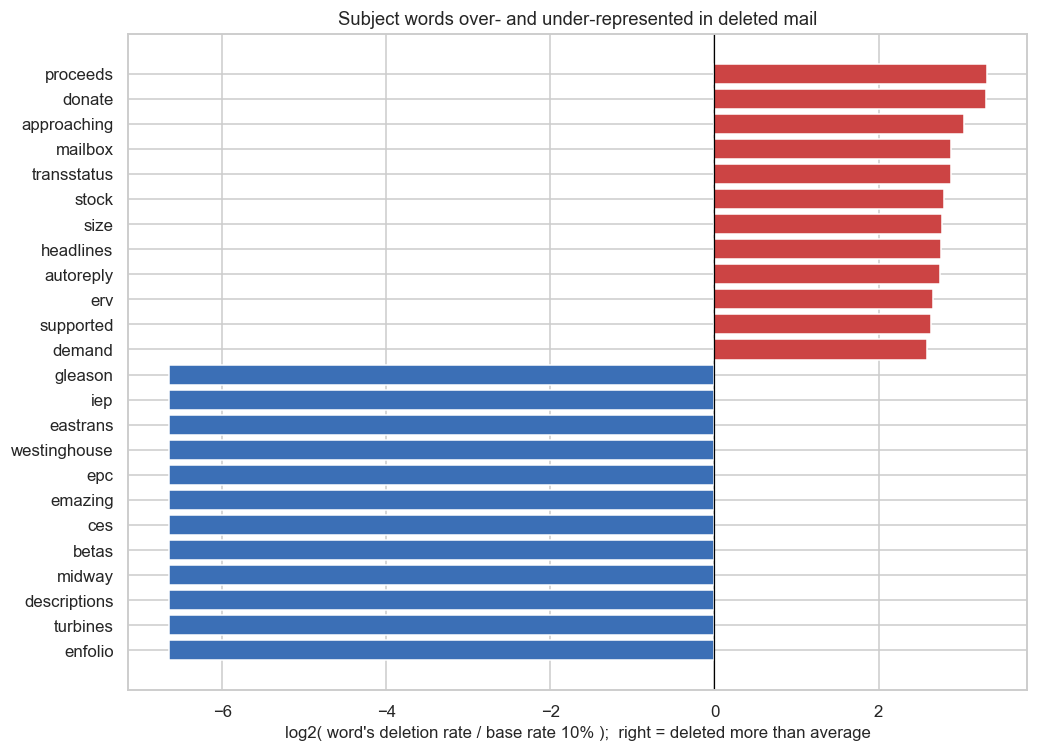

most over-deleted subject words:
       word  total  del_rate
     demand   2022  0.606330
  supported    218  0.623853
        erv    529  0.635161
  autoreply    326  0.674847
  headlines    380  0.681579
       size    355  0.684507
      stock   1755  0.695726
transstatus    218  0.738532
    mailbox    319  0.739812
approaching    273  0.824176
     donate   1127  0.997338
   proceeds   1126  0.999112


In [12]:
del_mask = rich["folder_group"].eq("deleted")
base = del_mask.mean()
dc, kc = Counter(), Counter()
for s, d in zip(rich["subject_norm"].fillna(""), del_mask):
    for w in set(WORD.findall(s.lower())):
        if w in STOP or len(w) <= 2:
            continue
        (dc if d else kc)[w] += 1

rowsf = []
for w in set(dc) | set(kc):
    tot = dc[w] + kc[w]
    if tot < 200:
        continue
    r = dc[w] / tot
    rowsf.append((w, tot, r, np.log2((r + 1e-3) / (base + 1e-3))))
wf = pd.DataFrame(rowsf, columns=["word", "total", "del_rate", "log2ratio"]).sort_values("log2ratio")
sel = pd.concat([wf.head(12), wf.tail(12)])

fig, ax = plt.subplots(figsize=(9.6, 7))
colors = ["#c44" if v > 0 else "#3b6fb6" for v in sel["log2ratio"]]
ax.barh(sel["word"], sel["log2ratio"], color=colors)
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel(f"log2( word's deletion rate / base rate {base:.0%} );  right = deleted more than average")
ax.set_title("Subject words over- and under-represented in deleted mail")
fig.tight_layout()
fig.savefig(PLOTS / "f2_deletion_topic_preference.png", dpi=140, bbox_inches="tight")
plt.show()

print("most over-deleted subject words:")
print(wf.tail(12)[["word", "total", "del_rate"]].to_string(index=False))

**What it shows.** Deletion is strongly topic-dependent. The base rate is about
ten percent of all mail, and two very different kinds of subject sit far above
it. The first is automated machine traffic: `autoreply`, `transstatus`,
`headlines`, `mailbox` (over-quota warnings), the system noise people sweep out
without reading. The second is a single human event. The words `donate`,
`proceeds`, `demand` and `stock` are deleted almost every time they appear,
because they belong to one mass-protest campaign, thousands of near-identical
messages headed roughly 'demand Ken Lay donate the proceeds from his Enron
stock sales', dumped into Ken Lay's mailbox after the collapse and swept
straight into his deleted folder. At the other end the under-deleted words are
the operational and deal vocabulary people kept: equipment and counterparties
like `turbines`, `westinghouse`, `abb`, `epc`, and pipeline names such as
`eastrans` and `cng`. Employees discarded noise and protest and filed the
business, so the deleted folders are emphatically not a random sample.

## G. Did people leaving drive deletion?

The last and most speculative point: is a person leaving the company a reason
their mail was deleted? The corpus does not record termination dates, so a
clean test is not possible, but there is a usable proxy. The last month in
which a mailbox shows any activity stands in for when that person stopped using
it. If departures drove deletion we would expect a mailbox's deletions to bunch
up in its final stretch, more than its ordinary mail does. The plot tests
exactly that, and reports the answer whether or not it supports the idea.

mailboxes tested: 125
median concentration ratio (last 60 days): 1.83
mailboxes that delete more near the end (ratio>1): 77%


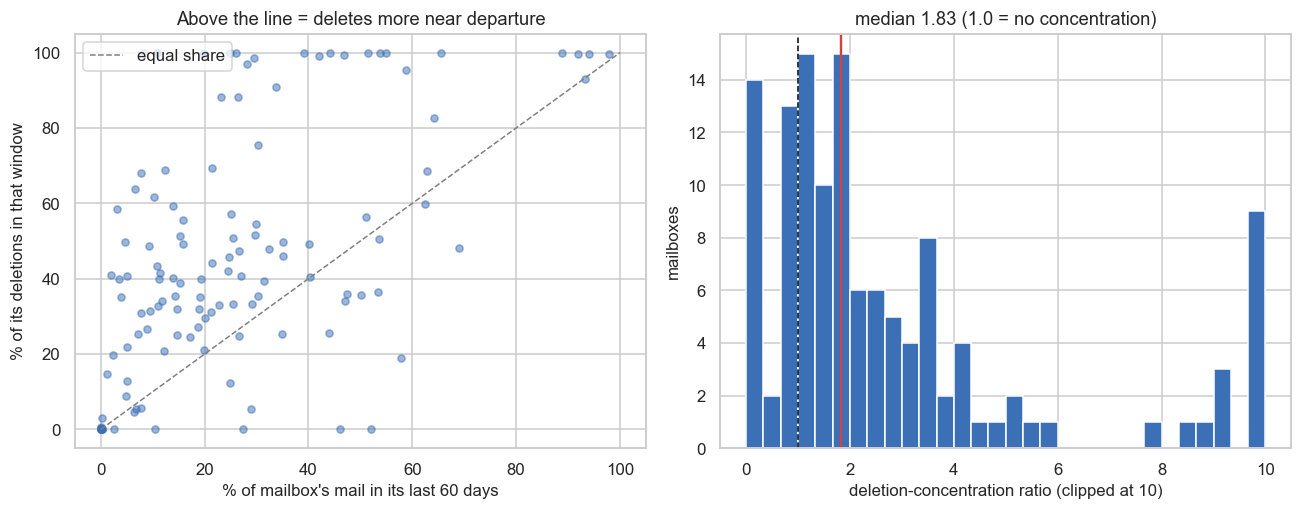

In [13]:
own = rich_t.copy()
own["deleted"] = own["folder_group"].eq("deleted")
last = own.groupby("user")["date"].max()

res = []
for u, sub in own.groupby("user"):
    if len(sub) < 200 or sub["deleted"].sum() < 20:
        continue
    win_start = last[u] - pd.Timedelta(days=60)
    in_win = sub["date"] >= win_start
    mail_share = in_win.mean()
    del_share = (in_win & sub["deleted"]).sum() / sub["deleted"].sum()
    if mail_share > 0:
        res.append((u, mail_share, del_share, del_share / mail_share))
dd = pd.DataFrame(res, columns=["user", "mail_share", "del_share", "ratio"]).dropna()
print(f"mailboxes tested: {len(dd)}")
print(f"median concentration ratio (last 60 days): {dd['ratio'].median():.2f}")
print(f"mailboxes that delete more near the end (ratio>1): {(dd['ratio'] > 1).mean():.0%}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
axes[0].scatter(dd["mail_share"] * 100, dd["del_share"] * 100, s=22, alpha=0.5, color="#3b6fb6")
lim = max(dd["mail_share"].max(), dd["del_share"].max()) * 100
axes[0].plot([0, lim], [0, lim], "--", color="gray", lw=1, label="equal share")
axes[0].set_xlabel("% of mailbox's mail in its last 60 days")
axes[0].set_ylabel("% of its deletions in that window")
axes[0].set_title("Above the line = deletes more near departure")
axes[0].legend(loc="upper left")
axes[1].hist(dd["ratio"].clip(upper=10), bins=30, color="#3b6fb6")
axes[1].axvline(1, color="black", ls="--", lw=1)
axes[1].axvline(dd["ratio"].median(), color="#c44", lw=1.6)
axes[1].set_xlabel("deletion-concentration ratio (clipped at 10)")
axes[1].set_ylabel("mailboxes")
axes[1].set_title(f"median {dd['ratio'].median():.2f} (1.0 = no concentration)")
fig.tight_layout()
fig.savefig(PLOTS / "g1_departure_vs_deletion.png", dpi=140, bbox_inches="tight")
plt.show()

**What it shows.** On its face the signal is strong and points the way the
reviewer guessed: deletions are end-loaded. Across the 125 testable mailboxes
the median concentration ratio is 1.83, and 77% of them delete a larger share
of their mail in their last sixty active days than they send or receive there,
so the cloud sits mostly above the equal-share line. Taken at face value that
says people clear mail out as they head for the door.

It cannot be read that cleanly, though, because of how the deleted folder
works. `deleted_items` is a live buffer that Outlook and its users empty
periodically, so whatever deletions survive to the 2002 snapshot are
disproportionately the recent ones; older deletions were already purged. That
alone produces an end-loaded pattern for almost every mailbox, whether or not
the person ever left. The last-activity proxy is also not a real termination
date. So the honest verdict is that the data is consistent with departures
prompting a clean-out, but the rolling-buffer artefact offers an equally good
explanation, and these headers cannot separate the two. The firmer result
remains section F's: deletion is driven by topic, dropping machine noise and
protest mail while keeping the business.

## Where this leaves us

Going through the review points in order: the activity heatmap now separates
volume from shape and colours empty cells white, so it no longer reads as busy
where it is idle. The completeness question has a concrete answer, the 517,401
files are about 252,000 distinct messages, small in size, spanning 1999 to
2002, complete on identity and timing but stripped of the threading headers,
and drawn from 150 mailboxes that see only a fifth of the internal people they
correspond with. Addresses now resolve to people, which both tidies the
round-trip chart and lets a genuine reciprocal clique surface. The California
and EES charts share a scale. Deletion turns out to be a steady, topic-driven
habit that discards routine traffic and keeps the substance, and the idea that
people leaving drove it cannot be settled, since the strong end-loaded pattern
in the deletions is equally explained by the deleted folder being a buffer that
is emptied over time.

The recurring caveat across all of this is coverage. Every count, every edge
and every rate describes 150 well-captured mailboxes, not Enron as a whole, and
the deduplication and missing-thread findings mean the raw file count and the
reply structure both need care before any modelling is built on top.